***PROYECTO- PREDICCION DE CAPTURA DE MERLUZA NEGRA BAJO CONDICIONES DE CALENTAMIENTO GLOBAL***

In [42]:
import pandas as pd

# URLs crudos desde tu GitHub
url_captura = "https://raw.githubusercontent.com/CristianCouto/prediccion_merluza_negra/main/data/raw/captura-puerto-flota-2019.csv"
url_clima   = "https://raw.githubusercontent.com/CristianCouto/prediccion_merluza_negra/main/data/raw/clima_ushuaia_rio_grande_2019.csv"
url_sst     = "https://raw.githubusercontent.com/CristianCouto/prediccion_merluza_negra/main/data/raw/sst_anomaly_tdf_2019_mensual.csv"

# 1. Captura mensual de merluza negra en Ushuaia
df_captura = pd.read_csv(url_captura, encoding="latin1")
df_merluza = df_captura[
    (df_captura["puerto"].str.lower().str.contains("ushuaia")) &
    (df_captura["especie"].str.lower().str.contains("merluza negra"))
].copy()
df_merluza["mes"] = pd.to_datetime(df_merluza["fecha"]).dt.month
df_captura_mensual = df_merluza.groupby("mes")["captura"].sum().reset_index()

# 2. Cargar clima desde archivo con cabecera extendida
df_clima = pd.read_csv(url_clima, skiprows=11)
df_clima.rename(columns={"PARAMETER": "variable"}, inplace=True)

# Pasar de ancho a largo (un valor por mes por variable)
df_clima_largo = df_clima.melt(id_vars=["variable", "YEAR"], var_name="mes", value_name="valor")
df_clima_2019 = df_clima_largo[df_clima_largo["YEAR"] == 2019].copy()

# Pivotear para obtener variables como columnas
df_clima_pivot = df_clima_2019.pivot_table(index="mes", columns="variable", values="valor").reset_index()
df_clima_pivot.columns.name = None
df_clima_pivot.rename(columns={
    "PRECTOTCORR": "precipitacion",
    "RH2M": "humedad",
    "T2M": "temperatura"
}, inplace=True)

# Filtrar meses válidos y convertir a número
meses_validos = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN",
                 "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
df_clima_pivot = df_clima_pivot[df_clima_pivot["mes"].isin(meses_validos)]
df_clima_pivot["mes"] = pd.to_datetime(df_clima_pivot["mes"], format="%b").dt.month

# 3. Cargar anomalía mensual SST
df_sst = pd.read_csv(url_sst)

# 4. Unir todo por 'mes'
df_merged = df_captura_mensual.merge(df_clima_pivot, on="mes").merge(df_sst, on="mes")
df_merged["provincia"] = "tierra del fuego"
df_merged["especie_agrupada"] = "merluza negra"

# Vista previa final
df_merged.head()


,mes,captura,precipitacion,humedad,temperatura,anom,provincia,especie_agrupada
0,1,4745,2.23,78.44,6.64,-0.473091,tierra del fuego,merluza negra
1,2,90,2.81,80.71,6.57,-0.137759,tierra del fuego,merluza negra
2,3,270,2.84,85.70,6.40,-0.213080,tierra del fuego,merluza negra
3,4,108,2.49,88.51,3.45,-0.094032,tierra del fuego,merluza negra
4,5,4706,1.57,91.30,2.11,-0.687903,tierra del fuego,merluza negra


In [48]:
# Aplicar filtros para quedarnos solo con capturas en Tierra del Fuego y especie Merluza Negra
df_proyecto = df_merged[
    (df_merged["provincia"].str.lower() == "tierra del fuego") &
    (df_merged["especie_agrupada"].str.lower() == "merluza negra")
].copy()

# Agrupar por mes para consolidar la información
df_modelo = df_proyecto.groupby("mes").agg({
    "captura": "sum",
    "precipitacion": "mean",
    "humedad": "mean",
    "temperatura": "mean"
}).reset_index()

df_modelo.head()


,mes,captura,precipitacion,humedad,temperatura
0,1,4745,2.23,78.44,6.64
1,2,90,2.81,80.71,6.57
2,3,270,2.84,85.70,6.40
3,4,108,2.49,88.51,3.45
4,5,4706,1.57,91.30,2.11


MAE: 1211.03
R²: -7.76


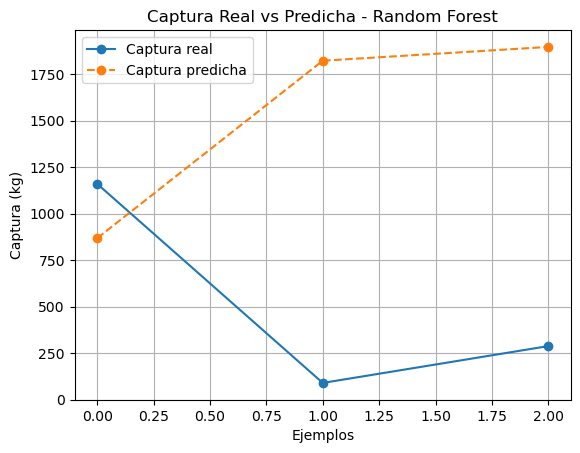

In [50]:
# Paso 1: Importar librerías de modelado y métricas
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Paso 2: Definir variables predictoras (X) y variable objetivo (y)
X = df_modelo[["precipitacion", "humedad", "temperatura"]]
y = df_modelo["captura"]

# Paso 3: Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Paso 4: Crear y entrenar el modelo
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Paso 5: Realizar predicciones
y_pred = model.predict(X_test)

# Paso 6: Evaluar el modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

# Paso 7: Graficar resultados
plt.plot(y_test.values, label="Captura real", marker='o')
plt.plot(y_pred, label="Captura predicha", marker='o', linestyle='--')
plt.xlabel("Ejemplos")
plt.ylabel("Captura (kg)")
plt.title("Captura Real vs Predicha - Random Forest")
plt.legend()
plt.grid(True)
plt.show()


MAE: 722.99
R²: 0.74


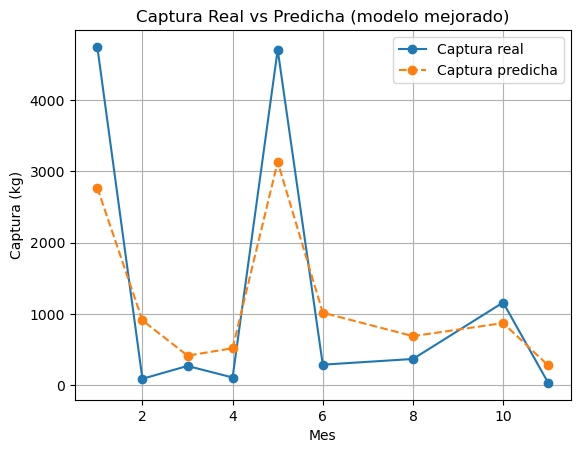

In [54]:
# Asegurarnos de tener anom2 creada
df_proyecto["anom2"] = df_proyecto["anom"] ** 2

# Agrupar por mes para calcular promedio de anom y anom²
anom_por_mes = df_proyecto.groupby("mes").agg({
    "anom": "mean",
    "anom2": "mean"
}).reset_index()

# Unir con df_modelo
df_modelo = pd.merge(df_modelo, anom_por_mes, on="mes")

# Definir variables predictoras y variable objetivo
X = df_modelo[["mes", "precipitacion", "humedad", "temperatura", "anom", "anom2"]]
y = df_modelo["captura"]

# Entrenar modelo Random Forest
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Predicciones
y_pred = model.predict(X)

# Evaluación
from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

# Visualización de resultados
import matplotlib.pyplot as plt

plt.plot(df_modelo["mes"], y, label="Captura real", marker='o')
plt.plot(df_modelo["mes"], y_pred, label="Captura predicha", marker='o', linestyle='--')
plt.xlabel("Mes")
plt.ylabel("Captura (kg)")
plt.title("Captura Real vs Predicha (modelo mejorado)")
plt.legend()
plt.grid(True)
plt.show()


In [56]:
# Obtener importancia de cada variable
importancia = model.feature_importances_

# Mostrar en DataFrame ordenado
importancia_df = pd.DataFrame({
    "variable": X.columns,
    "importancia": importancia
}).sort_values(by="importancia", ascending=False)

print(importancia_df)


        variable  importancia
1  precipitacion     0.357386
2        humedad     0.202726
0            mes     0.195954
3    temperatura     0.094151
4           anom     0.088101
5          anom2     0.061681


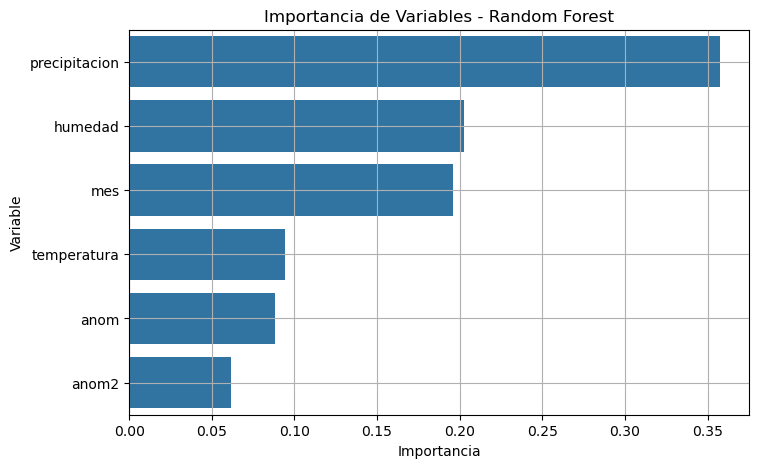

In [58]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(data=importancia_df, x="importancia", y="variable")
plt.title("Importancia de Variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.grid(True)
plt.show()


In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos desde GitHub
url_sst = "https://raw.githubusercontent.com/CristianCouto/prediccion_merluza_negra/main/data/raw/sst_anomaly_tdf_2019_mensual.csv"
url_captura = "https://raw.githubusercontent.com/CristianCouto/prediccion_merluza_negra/main/data/raw/captura-puerto-flota-2019.csv"

sst = pd.read_csv(url_sst)
captura = pd.read_csv(url_captura, encoding="latin1")

# Filtrar Merluza Negra capturada en Ushuaia
df_merluza = captura[
    (captura["puerto"].str.lower().str.contains("ushuaia")) &
    (captura["especie"].str.lower().str.contains("merluza negra"))
].copy()

# Vista previa opcional
df_merluza.head()


,fecha,flota,puerto,provincia,provincia_id,departamento,departamento_id,latitud,longitud,categoria,especie,especie_agrupada,captura
242,2019-01,Congeladores arrastreros,Ushuaia,Tierra del Fuego,94,Ushuaia,94015,-54.808106,-68.304301,Peces,Merluza negra,Merluza negra,4745
524,2019-02,Congeladores arrastreros,Ushuaia,Tierra del Fuego,94,Ushuaia,94015,-54.808106,-68.304301,Peces,Merluza negra,Merluza negra,90
836,2019-03,Congeladores arrastreros,Ushuaia,Tierra del Fuego,94,Ushuaia,94015,-54.808106,-68.304301,Peces,Merluza negra,Merluza negra,270
1178,2019-04,Congeladores arrastreros,Ushuaia,Tierra del Fuego,94,Ushuaia,94015,-54.808106,-68.304301,Peces,Merluza negra,Merluza negra,108
1525,2019-05,Congeladores arrastreros,Ushuaia,Tierra del Fuego,94,Ushuaia,94015,-54.808106,-68.304301,Peces,Merluza negra,Merluza negra,4706


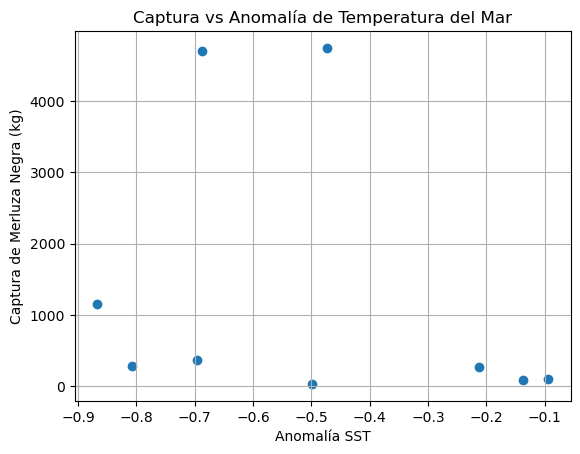

In [66]:
# Agrupar captura mensual
captura_mensual = df_merluza.copy()
captura_mensual["mes"] = pd.to_datetime(captura_mensual["fecha"]).dt.month
captura_mensual = captura_mensual.groupby("mes")["captura"].sum().reset_index()

# Unir con la anomalía mensual
df_vis = captura_mensual.merge(sst, on="mes")

# Graficar captura vs anom
plt.scatter(df_vis["anom"], df_vis["captura"])
plt.xlabel("Anomalía SST")
plt.ylabel("Captura de Merluza Negra (kg)")
plt.title("Captura vs Anomalía de Temperatura del Mar")
plt.grid(True)
plt.show()


*Escalar las variables predictoras*

MAE

In [83]:
from sklearn.preprocessing import MinMaxScaler

# Seleccionamos las variables predictoras y la variable objetivo
X = df_modelo[["mes", "precipitacion", "humedad", "temperatura", "anom", "anom2"]]
y = df_modelo["captura"]

# Escalamos X
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [88]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error

model = KNeighborsRegressor(n_neighbors=3)
loo = LeaveOneOut()

mae_scores = []

for train_index, test_index in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mae_scores.append(mae)

mae_promedio = sum(mae_scores) / len(mae_scores)
print(f"MAE promedio (KNN + escalado): {mae_promedio:.2f}")


MAE promedio (KNN + escalado): 2311.00


SVR

In [90]:
from sklearn.svm import SVR

model = SVR(kernel='rbf', C=100, epsilon=0.1)

mae_scores = []
for train_index, test_index in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mae_scores.append(mae)

mae_promedio = sum(mae_scores) / len(mae_scores)
print(f" MAE promedio (SVR): {mae_promedio:.2f}")

 MAE promedio (SVR): 1195.30
